--- Iniciando Simulação Paramétrica ---

--- Tabela de Resultados ---
 T2 [°C]  v2 [m^3/kg]  W_12 [kJ]  Q_12 [kJ]
     203      0.00002       0.00     548.04
     250      0.00002       0.01     911.37
     300      0.00002       0.01    1298.10
     400      0.00002       0.02    2085.70
     500      0.00003       0.02    2900.63


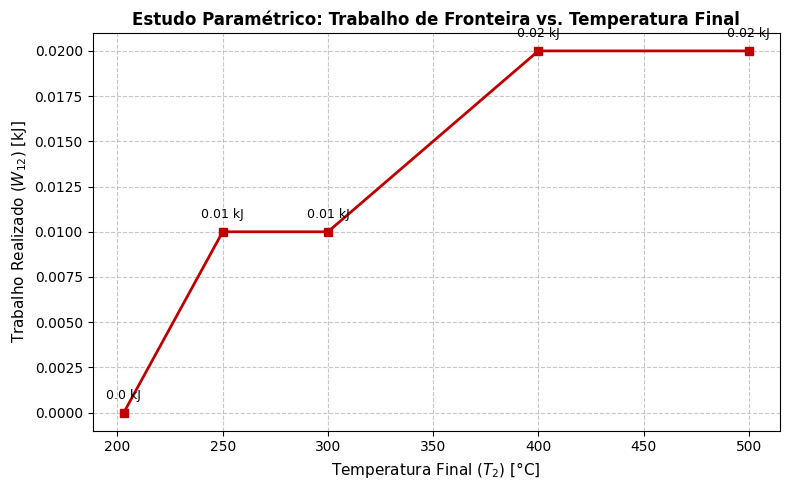

In [ ]:
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt
import pandas as pd
##Para que a simulação rode, favor instalar CoolProp usando "pip install CoolProp"
# =========================================================================
# EXERCÍCIO 01 - CENGEL 4-8 (PARAMETRIZADO)
# ASSUNTO: Trabalho de fronteira em fluido real (água)
# =========================================================================

print("--- Iniciando Simulação Paramétrica ---")

# --- DADOS DE ENTRADA ---
m = 4.95         # Massa total [kg]
P_kPa = 312      # Pressão de operação [kPa]
P_Pa = P_kPa * 1000  # Pressão [Pa] (O CoolProp trabalha com Pascal no SI)
x_1 = 1.0        # Título inicial (Vapor saturado seco)

# --- ESTADO 1: VAPOR SATURADO ---
# Obtendo volume específico inicial (V) e energia interna (U)
v_1 = CP.PropsSI('V', 'P', P_Pa, 'Q', x_1, 'Water')
u_1 = CP.PropsSI('U', 'P', P_Pa, 'Q', x_1, 'Water') / 1000  # Convertendo J/kg para kJ/kg

# --- ESTUDO PARAMÉTRICO ---
# Temperaturas finais desejadas para o estudo [°C]
temperaturas_C = [203, 250, 300, 400, 500]
resultados = []

for T2_C in temperaturas_C:
    T2_K = T2_C + 273.15  # O CoolProp exige temperatura em Kelvin

    # Estado 2: Vapor Superaquecido
    v_2 = CP.PropsSI('V', 'P', P_Pa, 'T', T2_K, 'Water')
    u_2 = CP.PropsSI('U', 'P', P_Pa, 'T', T2_K, 'Water') / 1000 # kJ/kg

    # Cálculo do Trabalho de Fronteira (W = P * dV)
    # Pressão em Pa * Volume em m^3 = Joules. Dividimos por 1000 para kJ.
    W_12 = m * P_Pa * (v_2 - v_1) / 1000

    # Cálculo da 1ª Lei (Calor Q)
    Q_12 = m * (u_2 - u_1) + W_12

    # Armazenando os dados na lista
    resultados.append({
        'T2 [°C]': T2_C,
        'v2 [m^3/kg]': round(v_2, 5),
        'W_12 [kJ]': round(W_12, 2),
        'Q_12 [kJ]': round(Q_12, 2)
    })

# --- EXIBIÇÃO DA TABELA ---
# Utilizando o Pandas para gerar uma tabela formatada no terminal
df = pd.DataFrame(resultados)
print("\n--- Tabela de Resultados ---")
print(df.to_string(index=False))

# --- GERAÇÃO DO GRÁFICO ---
plt.figure(figsize=(8, 5))
plt.plot(df['T2 [°C]'], df['W_12 [kJ]'], marker='s', linestyle='-', color='#c00000', linewidth=2)

# Formatação do gráfico
plt.title('Estudo Paramétrico: Trabalho de Fronteira vs. Temperatura Final', fontsize=12, fontweight='bold')
plt.xlabel('Temperatura Final ($T_2$) [°C]', fontsize=11)
plt.ylabel('Trabalho Realizado ($W_{12}$) [kJ]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionando rótulos de dados nos pontos do gráfico
for i, txt in enumerate(df['W_12 [kJ]']):
    plt.annotate(f"{txt} kJ", (df['T2 [°C]'][i], df['W_12 [kJ]'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Exibe o gráfico na tela
plt.tight_layout()

In [ ]:
pip install CoolProp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 54.8 MB/s eta 0:00:00
